In [45]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt


CONFIGURATION



In [46]:
NUM_CLIENTS=5
rounds=10
local_epochs=2
BATCH_SIZE=32
lr_rate=0.01

LOAD MNIST

In [47]:
(X_train,Y_train),(X_test,Y_test)=mnist.load_data()
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0
X_train=X_train.reshape(-1,28*28)
X_test=X_test.reshape(-1,28*28)

IID PARTITION

In [48]:
def create_clients(x,y,num_clients):
  idx=np.random.permutation(len(x))
  x=x[idx]
  y=y[idx]
  size=len(x)//num_clients
  clients={}

  for i in range(num_clients):
    start=i*size
    if(i!=num_clients-1):
      end=(i+1)*size
    else:
      end=len(x)
    clients[f"client_{i+1}"]=[x[start:end],y[start:end]]
  return clients

clients=create_clients(X_train,Y_train,NUM_CLIENTS)

In [49]:
def create_model():
  model=tf.keras.Sequential([
      Input(shape=(784,)),
      Dense(128,activation='relu'),
      Dense(64,activation='relu'),
      Dense(10,activation='softmax')
  ])

  model.compile(
     optimizer=SGD(learning_rate=lr_rate),
     loss='sparse_categorical_crossentropy',
     metrics=['accuracy']
 )
  return model

global_model=create_model()

FEDAvg

In [50]:
def scale_weights(weights,factor):
  return [factor*w for w in weights]
def sum_scaled_weights(weight_list):
  avg=[]
  for weights in zip(*weight_list):
    avg.append(tf.reduce_sum(weights,axis=0))
  return avg

TRAINING LOOP

In [51]:
total_samples = sum(len(v[0]) for v in clients.values())
history=[]


In [52]:
for rnd in range(rounds):
  print(f"\n=======Round{rnd+1}=======")
  global_weights=global_model.get_weights()
  scaled_local_weights=[]
  for name,(cx,cy) in clients.items():
    local_model=create_model()
    local_model.set_weights(global_weights)
    local_model.fit(cx,cy,epochs=local_epochs,batch_size=BATCH_SIZE, verbose=1)
    local_weights=local_model.get_weights()
    factor=len(cx)/total_samples
    scaled_local_weights.append(scale_weights(local_weights,factor))
  averaged_weights=sum_scaled_weights(scaled_local_weights)
  global_model.set_weights(averaged_weights)
  loss,acc=global_model.evaluate(X_test,Y_test,verbose=1)
  history.append(acc)
  print('Test Accuracy:',acc)




=======Round1=======
Epoch 1/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6547 - loss: 1.3602
Epoch 2/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8587 - loss: 0.5691
Epoch 1/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6394 - loss: 1.3566
Epoch 2/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8562 - loss: 0.5740
Epoch 1/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6453 - loss: 1.3542
Epoch 2/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8581 - loss: 0.5663
Epoch 1/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6454 - loss: 1.3601
Epoch 2/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8533 - loss: 0.5691
Epoch 1/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6418 - loss: 1.3534
Epoch 2/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8615 - loss: 0.5602
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8828 - loss: 0.4506
Test Accuracy: 0.8827999830245972

=======Round2====

In [53]:
print('Training Finished')
print('Final Accuracy:',history[-1])

Training Finished
Final Accuracy: 0.9495999813079834


CODE GENERATED BY GEMINI TO VISUALIZE

Saved plot to fedavg_accuracy.png


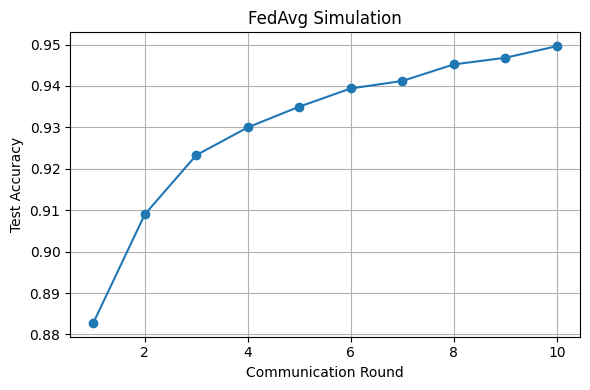

In [55]:
try:
    plt.figure(figsize=(6,4))
    plt.plot(range(1, rounds+1), history, marker="o")
    plt.xlabel("Communication Round")
    plt.ylabel("Test Accuracy")
    plt.title("FedAvg Simulation")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("fedavg_accuracy.png")
    print("Saved plot to fedavg_accuracy.png")
except Exception as e:
    print("Plot skipped:", e)